# GROUP 1 PROJECT - DATA ANALYSIS 

## PRICES AND VOLATILITY ##

### Objective: Build the European electricity price analysis module. ###
REYES ALBO PORRO
  
KILLIAN BUJON-GIRONE 

DARIJA KNEZEVIC 

CLEMENT NEDONSEL 

LAURE PRINET 

MIGUEL VARELA ROMAN 
    

----------------
----------------

# API connection 

**Source:**  SMARD / Bundesnetzagentur -> ENTSO-E

As on SMARD at this moment is only possible to download data, and not to access it through an API and on webpage is written this: "SMARD receives the data directly from the European Network of Transmission System Operators for Electricity (ENTSO-E). Only data verified by the Bundesnetzagentur is published on SMARD.", ENTSO-E API is used instead.

Original code owner: Killan 

Owner: Darija 

Added Germany and saving to csv


In [1]:
!pip install entsoe-py
from entsoe import EntsoePandasClient
import pandas as pd
#DL the module entsoe 

client = EntsoePandasClient(
    api_key='5bcf63bf-87d7-4aa5-8bfb-040cbc4c4af0'
)
##This is Kilian's token 


start = pd.Timestamp(
    '2025-01-01',
    tz='Europe/Brussels'
)

end = pd.Timestamp(
    '2025-03-01',
    tz='Europe/Brussels'
)

es = client.query_day_ahead_prices(
    'ES',
    start=start,
    end=end
)

fr = client.query_day_ahead_prices(
    'FR',
    start=start,
    end=end
)

de = client.query_day_ahead_prices(
    'DE_LU',
    start=start,
    end=end
)

df = pd.DataFrame({
    'Spain': es,
    'France': fr,
    'Germany': de
})

df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["date"] = df.index.date

print(df.head())



# -----------------------------
# SAVE TO CSV
# -----------------------------
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/day_ahead_prices_2025_Q1.csv")

print("CSV saved successfully ✅")
print(df.head())

                            Spain  France  Germany  hour  day_of_week  month  \
2024-12-31 23:00:00+00:00  134.49   12.36     2.16    23            1     12   
2025-01-01 00:00:00+00:00  131.59   18.92     1.60     0            2      1   
2025-01-01 01:00:00+00:00  131.49   16.66     0.00     1            2      1   
2025-01-01 02:00:00+00:00  131.42   13.10    -0.01     2            2      1   
2025-01-01 03:00:00+00:00  120.49    5.90    -0.01     3            2      1   

                                 date  
2024-12-31 23:00:00+00:00  2024-12-31  
2025-01-01 00:00:00+00:00  2025-01-01  
2025-01-01 01:00:00+00:00  2025-01-01  
2025-01-01 02:00:00+00:00  2025-01-01  
2025-01-01 03:00:00+00:00  2025-01-01  
CSV saved successfully ✅
                            Spain  France  Germany  hour  day_of_week  month  \
2024-12-31 23:00:00+00:00  134.49   12.36     2.16    23            1     12   
2025-01-01 00:00:00+00:00  131.59   18.92     1.60     0            2      1   
2025-01-01 01:

-------------
-------------

# Statistical Analysis

Owner: Darija


In [2]:
# -----------------------------
# READ DATA FROM CSV
# -----------------------------

df = pd.read_csv(
    "data/day_ahead_prices_2025_Q1.csv",
    index_col=0,
    parse_dates=True
)

print("CSV loaded successfully ✅")
print(df.head())

CSV loaded successfully ✅
                            Spain  France  Germany  hour  day_of_week  month  \
2024-12-31 23:00:00+00:00  134.49   12.36     2.16    23            1     12   
2025-01-01 00:00:00+00:00  131.59   18.92     1.60     0            2      1   
2025-01-01 01:00:00+00:00  131.49   16.66     0.00     1            2      1   
2025-01-01 02:00:00+00:00  131.42   13.10    -0.01     2            2      1   
2025-01-01 03:00:00+00:00  120.49    5.90    -0.01     3            2      1   

                                 date  
2024-12-31 23:00:00+00:00  2024-12-31  
2025-01-01 00:00:00+00:00  2025-01-01  
2025-01-01 01:00:00+00:00  2025-01-01  
2025-01-01 02:00:00+00:00  2025-01-01  
2025-01-01 03:00:00+00:00  2025-01-01  


In [3]:
def statistical_summary(df, country):
    return {
        "mean": df[country].mean(),
        "median": df[country].median(),
        "std": df[country].std(),
        "variance": df[country].var(),
        "min": df[country].min(),
        "max": df[country].max(),
        "range": df[country].max() - df[country].min(),
        "skewness": df[country].skew(),
        "kurtosis": df[country].kurtosis(),
        "q25": df[country].quantile(0.25),
        "q50": df[country].quantile(0.50),
        "q75": df[country].quantile(0.75),
    }

stats_es = statistical_summary(df, "Spain")
stats_fr = statistical_summary(df, "France")
stats_de = statistical_summary(df, "Germany")

stats_df = pd.DataFrame({
    "Spain": stats_es,
    "France": stats_fr,
    "Germany": stats_de
})

stats_df

,Spain,France,Germany
mean,102.205688,111.952802,120.970713
median,109.400000,118.560000,120.370000
std,46.290052,45.831333,50.550235
variance,2142.768883,2100.511048,2555.326275
min,0.000000,0.400000,-1.010000
max,240.000000,473.280000,583.400000
range,240.000000,472.880000,584.410000
skewness,-0.326810,0.139881,1.449417
kurtosis,-0.204253,3.128884,9.846298
q25,72.880000,89.940000,93.860000


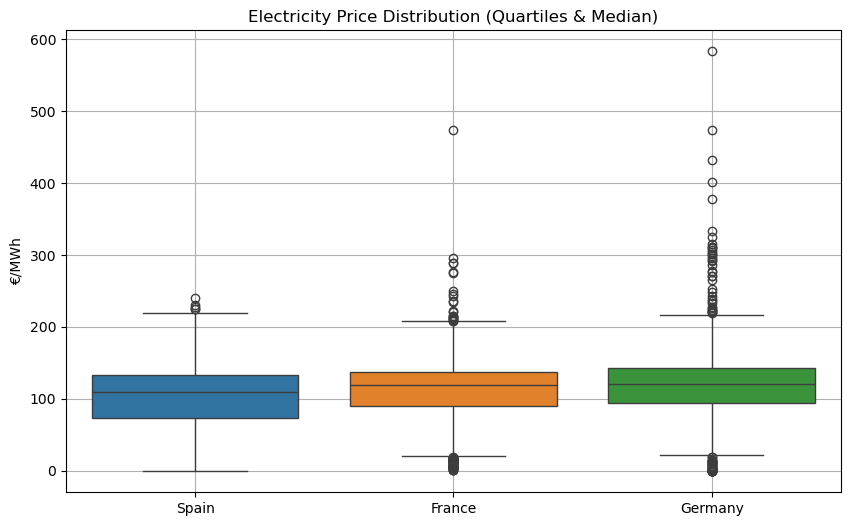

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplot(df):
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df[['Spain', 'France', 'Germany']])
    plt.title("Electricity Price Distribution (Quartiles & Median)")
    plt.ylabel("€/MWh")
    plt.grid(True)
    plt.show()

plot_boxplot(df)

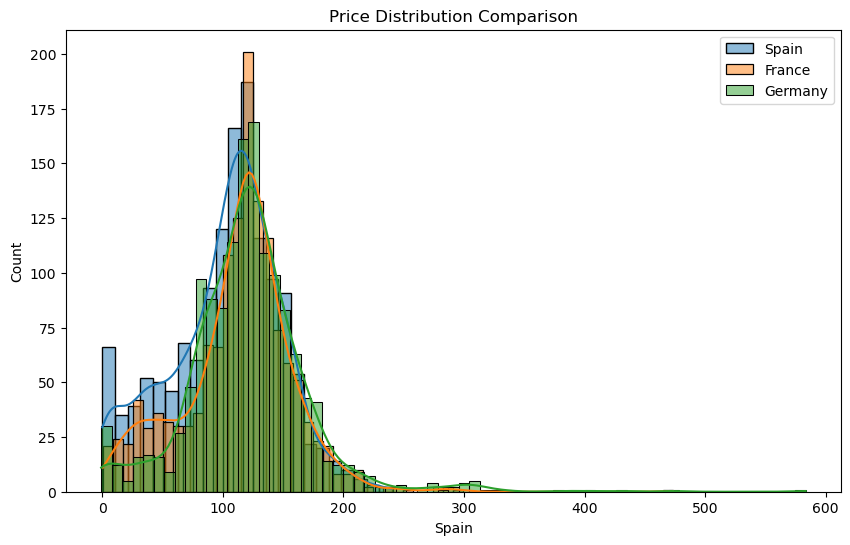

In [5]:
def plot_distribution(df):
    plt.figure(figsize=(10,6))
    sns.histplot(df['Spain'], kde=True, label='Spain', alpha=0.5)
    sns.histplot(df['France'], kde=True, label='France', alpha=0.5)
    sns.histplot(df['Germany'], kde=True, label='Germany', alpha=0.5)
    plt.legend()
    plt.title("Price Distribution Comparison")
    plt.show()

plot_distribution(df)

In [6]:
def risk_index(df, country):
    return df[country].std() / df[country].mean()

print("Risk ES:", risk_index(df, "Spain"))
print("Risk FR:", risk_index(df, "France"))
print("Risk DE:", risk_index(df, "Germany"))

Risk ES: 0.4529107189255022
Risk FR: 0.4093808454046379
Risk DE: 0.41787168154145066


--------
--------

# Volatility Analysis

--- Global Volatility (Spain) ---
std_dev: 46.29
mean: 102.21
min: 0.00
max: 240.00
range: 240.00
coef_variation: 45.29

--- Global Volatility (France) ---
std_dev: 45.83
mean: 111.95
min: 0.40
max: 473.28
range: 472.88
coef_variation: 40.94

--- Global Volatility (Germany) ---
std_dev: 50.55
mean: 120.97
min: -1.01
max: 583.40
range: 584.41
coef_variation: 41.79


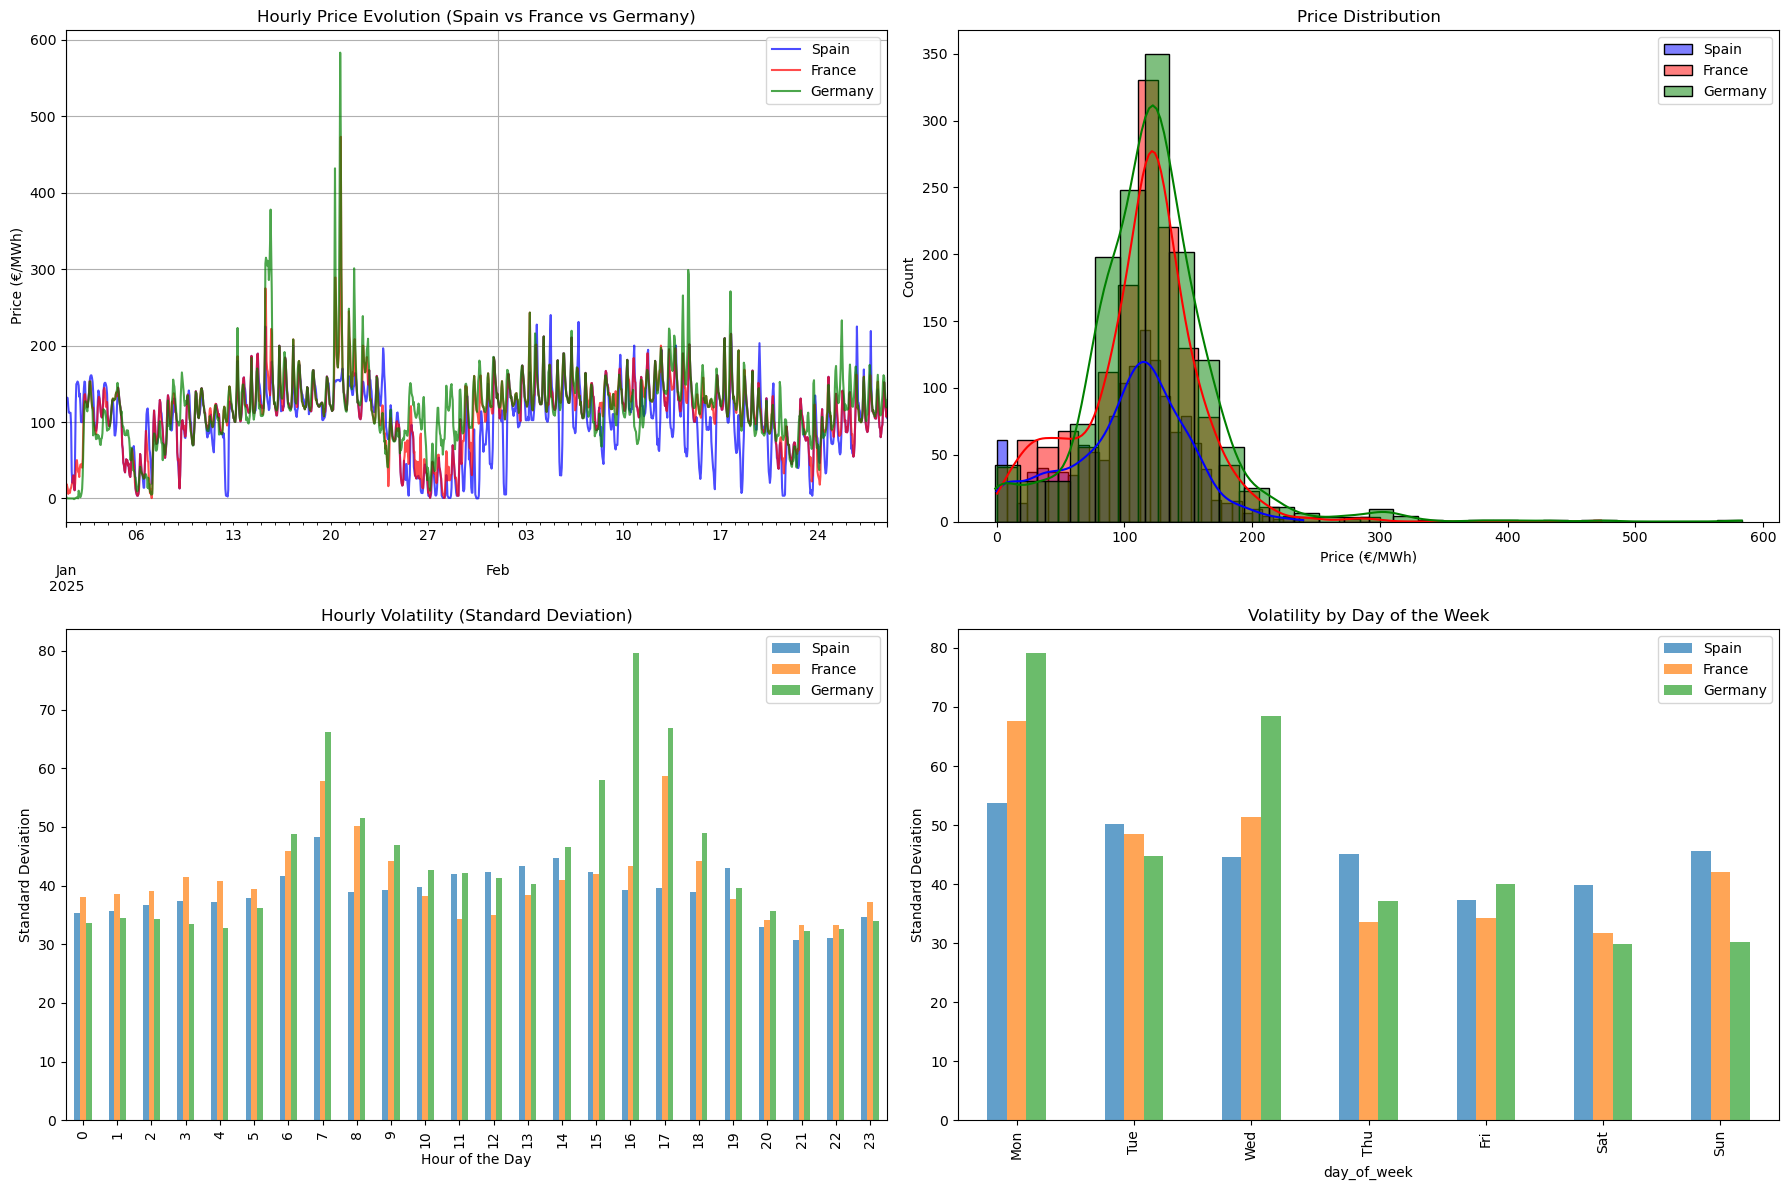

C:\Users\darij\AppData\Local\Temp\ipykernel_2368\3037082084.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month'] = df_filtered['month'].map({1: 'January', 2: 'February'})


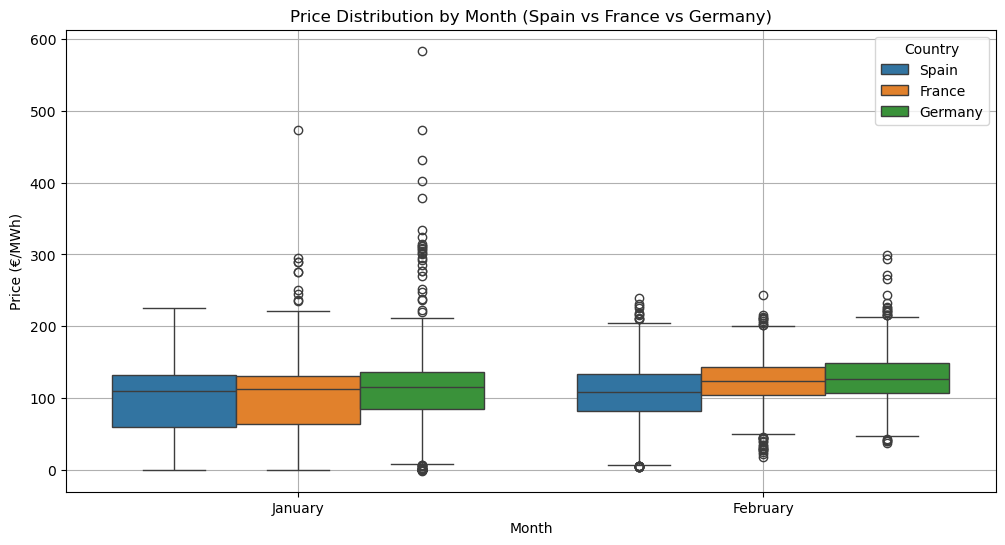

In [7]:
##VOLATILITY ANALYSIS

# --- 3. Volatility Calculation ---
def calculate_volatility(df, country):
    # Global volatility
    volatility = {
        "std_dev": df[country].std(),
        "mean": df[country].mean(),
        "min": df[country].min(),
        "max": df[country].max(),
        "range": df[country].max() - df[country].min(),
        "coef_variation": (df[country].std() / df[country].mean()) * 100,
    }

    # Hourly volatility
    hourly_volatility = df.groupby("hour")[country].agg(["mean", "std", "min", "max"])

    # Daily volatility (by day of the week)
    daily_volatility = df.groupby("day_of_week")[country].agg(["mean", "std", "min", "max"])

    # Monthly volatility
    monthly_volatility = df.groupby("month")[country].agg(["mean", "std", "min", "max"])

    return volatility, hourly_volatility, daily_volatility, monthly_volatility

# Calculate for Spain and France
volatility_es, hourly_vol_es, daily_vol_es, monthly_vol_es = calculate_volatility(df, 'Spain')
volatility_fr, hourly_vol_fr, daily_vol_fr, monthly_vol_fr = calculate_volatility(df, 'France')
volatility_de, hourly_vol_de, daily_vol_de, monthly_vol_de = calculate_volatility(df, 'Germany')

# --- 4. Visualizations ---
def plot_comparative_volatility(df):
    plt.figure(figsize=(18, 12))

    # 4.1. Time series of prices (Spain vs France)
    plt.subplot(2, 2, 1)
    df['Spain'].plot(label='Spain', color='blue', alpha=0.7)
    df['France'].plot(label='France', color='red', alpha=0.7)
    df['Germany'].plot(label='Germany', color='green', alpha=0.7)
    plt.title("Hourly Price Evolution (Spain vs France vs Germany)")
    plt.ylabel("Price (€/MWh)")
    plt.legend()
    plt.grid(True)

    # 4.2. Price distribution (Spain vs France vs Germany)
    plt.subplot(2, 2, 2)
    sns.histplot(df['Spain'], bins=30, kde=True, color='blue', label='Spain', alpha=0.5)
    sns.histplot(df['France'], bins=30, kde=True, color='red', label='France', alpha=0.5)
    sns.histplot(df['Germany'], bins=30, kde=True, color='green', label='Germany', alpha=0.5)
    plt.title("Price Distribution")
    plt.xlabel("Price (€/MWh)")
    plt.legend()

    # 4.3. Hourly volatility (standard deviation)
    plt.subplot(2, 2, 3)
    hourly_std = df.groupby("hour")[['Spain', 'France', 'Germany']].std()
    hourly_std.plot(kind='bar', ax=plt.gca(), title="Hourly Volatility (Standard Deviation)", alpha=0.7)
    plt.xlabel("Hour of the Day")
    plt.ylabel("Standard Deviation")

    # 4.4. Weekly volatility (standard deviation by day of the week)
    plt.subplot(2, 2, 4)
    daily_std = df.groupby("day_of_week")[['Spain', 'France', 'Germany']].std()
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    daily_std.plot(kind='bar', ax=plt.gca(), title="Volatility by Day of the Week", alpha=0.7)
    plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    plt.ylabel("Standard Deviation")

    plt.tight_layout()
    plt.show()

    # 4.5. Boxplot by month (Spain vs France vs Germany)
    plt.figure(figsize=(12, 6))
    df_melted = df.reset_index().melt(id_vars=['hour', 'day_of_week', 'month', 'date'],
                                      value_vars=['Spain', 'France', 'Germany'],
                                      var_name='Country', value_name='Price')
    df_filtered = df_melted[df_melted['month'].isin([1, 2])]
    df_filtered['month'] = df_filtered['month'].map({1: 'January', 2: 'February'})
    sns.boxplot(x="month", y="Price", hue="Country", data=df_filtered)
    plt.title("Price Distribution by Month (Spain vs France vs Germany)")
    plt.xlabel("Month")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.show()

# --- 5. Display Results ---
print("--- Global Volatility (Spain) ---")
for k, v in volatility_es.items():
    print(f"{k}: {v:.2f}")

print("\n--- Global Volatility (France) ---")
for k, v in volatility_fr.items():
    print(f"{k}: {v:.2f}")

print("\n--- Global Volatility (Germany) ---")
for k, v in volatility_de.items():
    print(f"{k}: {v:.2f}")

# Generate visualizations
plot_comparative_volatility(df)

---------------
---------------
 # Heatmaps: another way to study electricity prices

In [8]:
df = df.iloc[1:]  #To start with the 1st hours of the 1st of January
df.head()

,Spain,France,Germany,hour,day_of_week,month,date
2025-01-01 00:00:00+00:00,131.59,18.92,1.60,0,2,1,2025-01-01
2025-01-01 01:00:00+00:00,131.49,16.66,0.00,1,2,1,2025-01-01
2025-01-01 02:00:00+00:00,131.42,13.10,-0.01,2,2,1,2025-01-01
2025-01-01 03:00:00+00:00,120.49,5.90,-0.01,3,2,1,2025-01-01
2025-01-01 04:00:00+00:00,112.30,9.27,-0.06,4,2,1,2025-01-01


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

#Creation of two columns : Day and Hour
df["Date"] = df.index.strftime("%Y-%m-%d")  # Format : "2025-01-15"
df["Hour"] = df.index.strftime("%H:00")     # Format : "23:00"
pivot_df = df.pivot(index="Hour", columns="Date", values=["France", "Spain","Germany"]) #Hour becomes the index and the dates are columns
pivot_df.head()

France                                                         \
Date  2025-01-01 2025-01-02 2025-01-03 2025-01-04 2025-01-05 2025-01-06   
Hour                                                                      
00:00      18.92      44.10      95.18     101.00      70.50       8.35   
01:00      16.66      44.70      89.94      95.53      64.81       5.23   
02:00      13.10      42.92      87.67      94.33      46.70       3.52   
03:00       5.90      40.15      84.06      96.62      43.87       3.52   
04:00       9.27      52.51      92.25     102.63      36.61       5.61   

                                                   ...    Germany             \
Date  2025-01-07 2025-01-08 2025-01-09 2025-01-10  ... 2025-02-19 2025-02-20   
Hour                                               ...                         
00:00       6.66      69.50      49.90      80.25  ...      99.29      85.20   
01:00      12.54      59.97      51.86      72.09  ...      99.60      84.56   
02:00       5.59      53.00      25.61      69.94  ...      97.29      83.64   
03:00       0.40      59.52      13.01      70.07  ...      94.50      82.18   
04:00      12.49      70.20      30.29      85.06  ...      97.48      83.84   

                                                                         \
Date  2025-02-21 2025-02-22 2025-02-23 2025-02-24 2025-02-25 2025-02-26   
Hour                                                                      
00:00      74.99      48.62      84.99      67.99      89.91     119.82   
01:00      79.80      47.96      86.21      40.98      93.39     116.94   
02:00      83.40      42.62      83.63      37.10      93.86     115.98   
03:00      82.40      41.20      85.77      65.34      97.43     116.56   
04:00      82.03      49.15      87.33      70.03     105.78     117.27   

                             
Date  2025-02-27 2025-02-28  
Hour                         
00:00     103.81     110.54  
01:00     101.24     109.38  
02:00      99.60     106.93  
03:00     100.43     112.03  
04:00     105.87     112.63  

[5 rows x 177 columns]

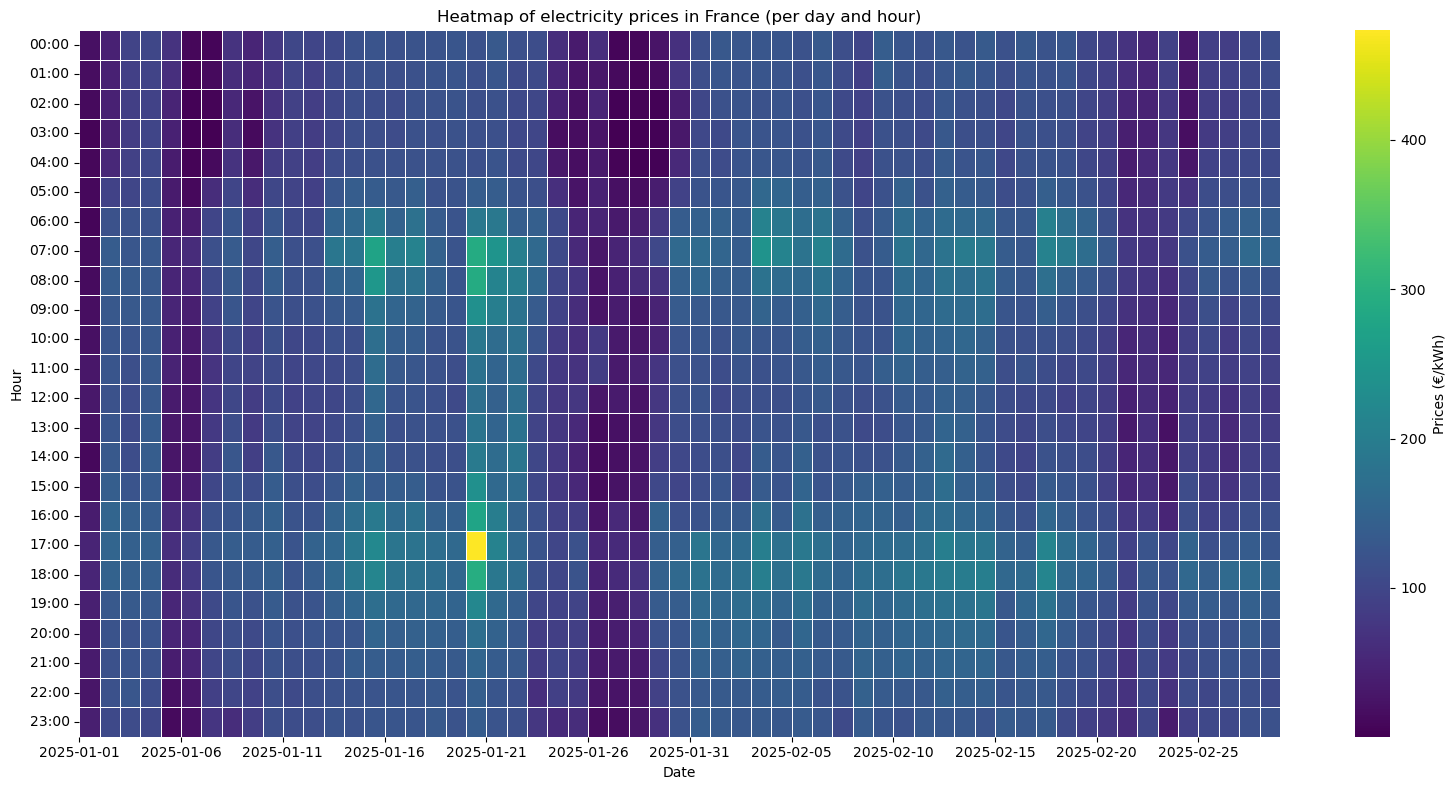

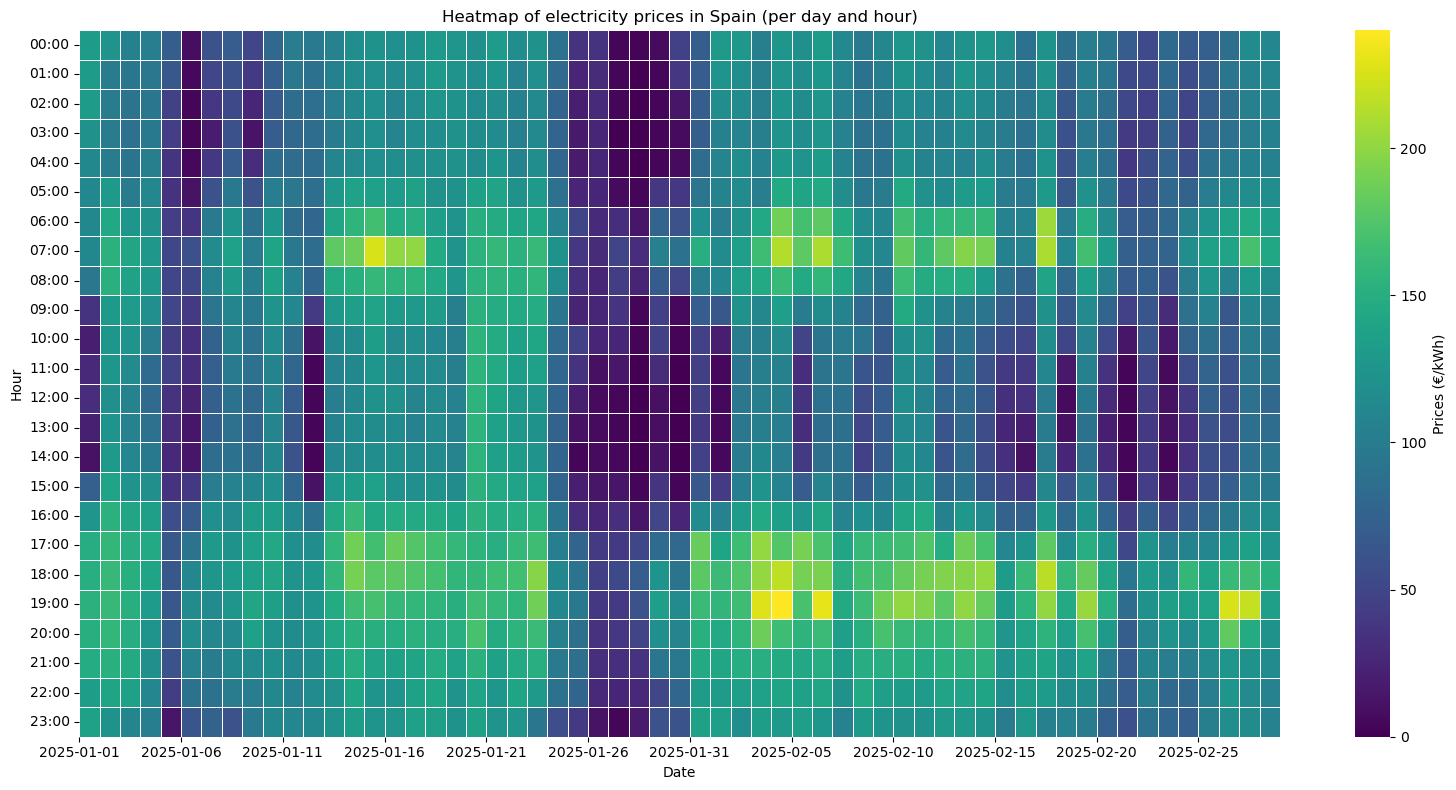

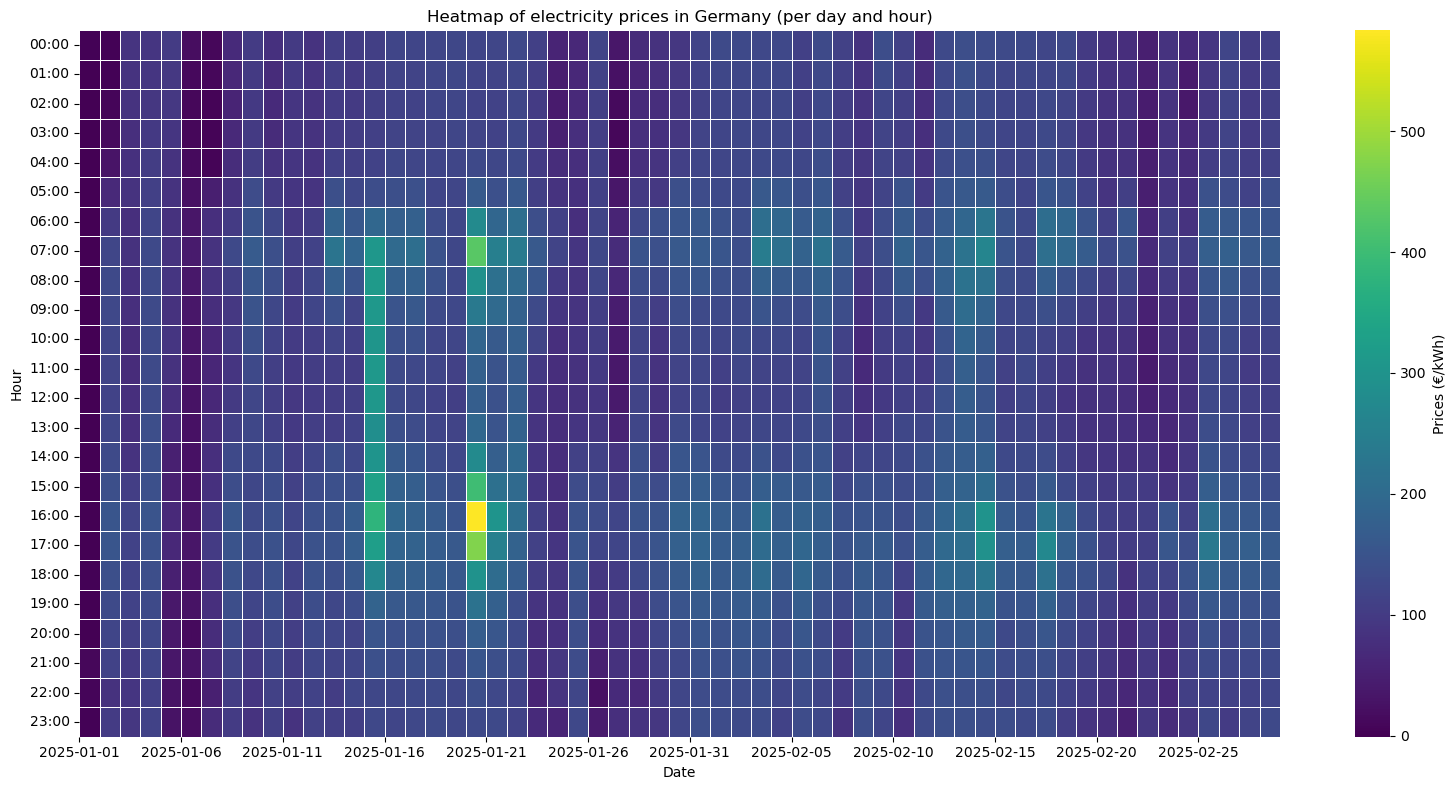

In [10]:
#Heatmap with x axis = day ; y axis = hour ; colour (heat) = prices
for country in ["France", "Spain","Germany"]:
    plt.figure(figsize=(16, 8))
    sns.heatmap(
        pivot_df[country],
        cmap="viridis", #the color code
        annot=False, #prices won't appear for each set {day, hour} or else too much information
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={'label': 'Prices (€/kWh)'} #Color (heat) legend
    )
    plt.title(f"Heatmap of electricity prices in {country} (per day and hour)")
    plt.xlabel("Date")
    plt.ylabel("Hour")
    Xticks=pivot_df["France"].columns #we'll have to select the ticks for the x axis that will appear
    plt.xticks(
        ticks=range(0, len(Xticks), 5),  #Their position
        labels=Xticks[::5],  #Only 1 out of 5 ticks will be displayed with the dates
        rotation=0) #Writing horizontally the dates
    plt.tight_layout()
    plt.show()


Those heatmaps show the electricity prices in each country, over three months, for each hour of the day. The more yellow the square is, the more expensive the electricity was that day at that time!

A first analysis of these maps is that, in general, Spain has more expensive electricity. This must be caused by the lack of flexibility caused by the important amount of solar and wind. 

Let's thus go more into details with those differences with other heatmaps:

In [11]:
#dataframe new columns for differences between country
df['Spain_France']=df['Spain']-df['France']
df['France_Germany']=df['France']-df['Germany']
df['Spain_Germany']=df['Spain']-df['Germany']
Min_spread={'SF':df['Spain_France'].min(), "SG": df['Spain_Germany'].min(), "FG": df['France_Germany'].min()}
Max_spread={'SF':df['Spain_France'].max(), "SG": df['Spain_Germany'].max(), "FG": df['France_Germany'].max()}
df.head()

,Spain,France,Germany,hour,day_of_week,month,date,Date,Hour,Spain_France,France_Germany,Spain_Germany
2025-01-01 00:00:00+00:00,131.59,18.92,1.60,0,2,1,2025-01-01,2025-01-01,00:00,112.67,17.32,129.99
2025-01-01 01:00:00+00:00,131.49,16.66,0.00,1,2,1,2025-01-01,2025-01-01,01:00,114.83,16.66,131.49
2025-01-01 02:00:00+00:00,131.42,13.10,-0.01,2,2,1,2025-01-01,2025-01-01,02:00,118.32,13.11,131.43
2025-01-01 03:00:00+00:00,120.49,5.90,-0.01,3,2,1,2025-01-01,2025-01-01,03:00,114.59,5.91,120.50
2025-01-01 04:00:00+00:00,112.30,9.27,-0.06,4,2,1,2025-01-01,2025-01-01,04:00,103.03,9.33,112.36


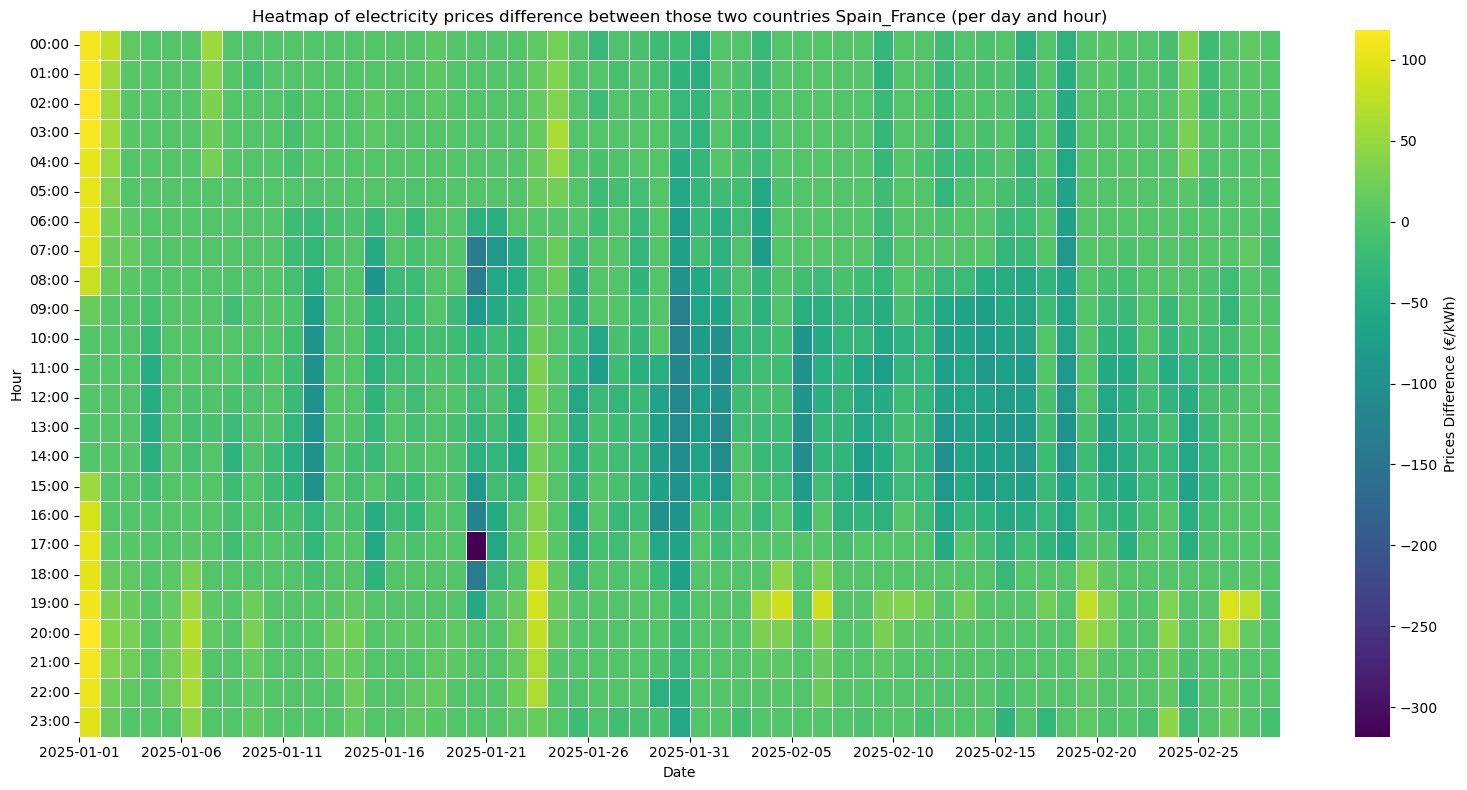

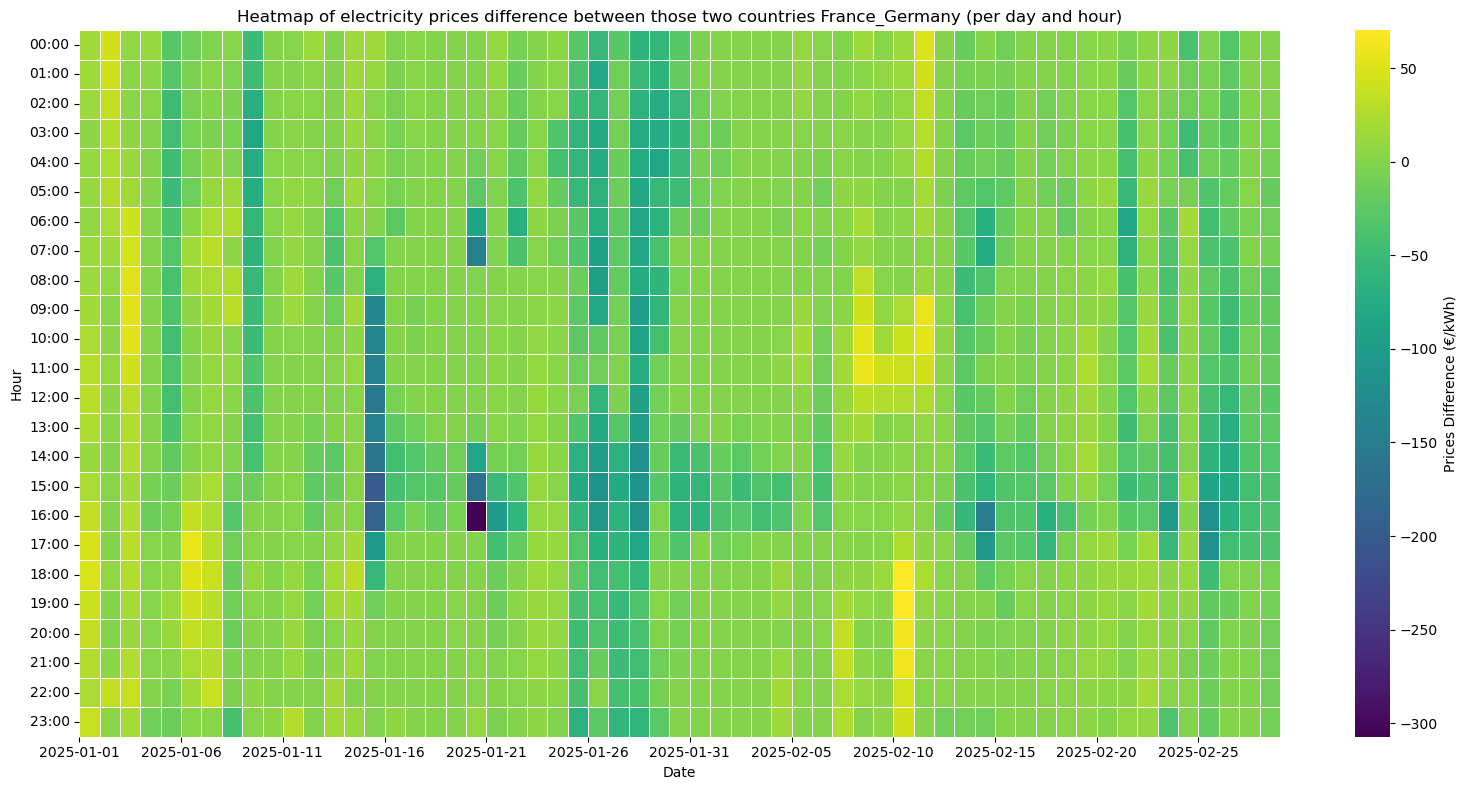

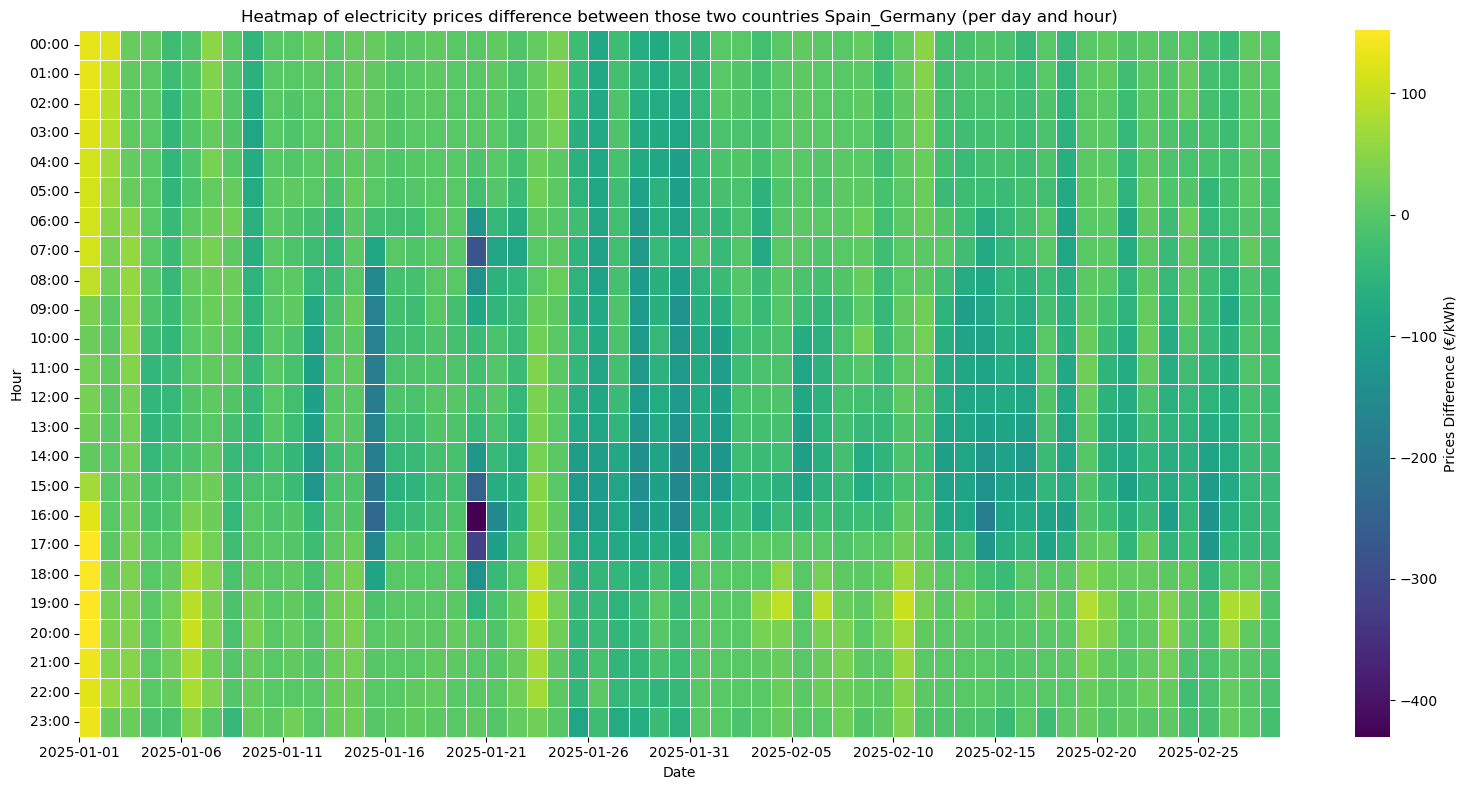

In [12]:
for countries in ["Spain_France", "France_Germany","Spain_Germany"]:
    pivot = df.pivot(index="Hour", columns="Date", values=[countries]) #Hour becomes the index and the dates are columns
    plt.figure(figsize=(16, 8))
    sns.heatmap(
                pivot[countries],
                cmap="viridis", #the color code
                annot=False, #prices won't appear for each set {day, hour} or else too much information
                fmt=".2f",
                linewidths=0.5,
                cbar_kws={'label': 'Prices Difference (€/kWh)'} #Color (heat) legend
            )
    plt.title(f"Heatmap of electricity prices difference between those two countries {countries} (per day and hour)")
    plt.xlabel("Date")
    plt.ylabel("Hour")

    plt.xticks(
                ticks=range(0, len(Xticks), 5),  #Their position
                labels=Xticks[::5],  #Only 1 out of 5 ticks will be displayed with the dates
                rotation=0) #Writing horizontally the dates
    plt.tight_layout()
    plt.show()

What is interesting pointing out here are the different colour (heat) scales: the prices difference seams to be the greatest between Spain and Germany across those three months.

Moreover, what we observe easily is that, during daytime hours (between 9 AM and 6 PM), Spain has cheaper prices than both other countries. It isn't the case at other hours (due to the lack of solar production). 

---
---
## Advanced price Analysis, alerts and forecasting module ##

### Data download from ENTSO-E API & storage ###

In [13]:
import os
import logging
import pandas as pd
import numpy as np
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key='5bcf63bf-87d7-4aa5-8bfb-040cbc4c4af0')

start = pd.Timestamp('2025-01-01', tz='Europe/Brussels')
end = pd.Timestamp('2025-03-01', tz='Europe/Brussels')

print("Downloading market prices...")
try:
    es = client.query_day_ahead_prices('ES', start=start, end=end)
    fr = client.query_day_ahead_prices('FR', start=start, end=end)
    de = client.query_day_ahead_prices('DE_LU', start=start, end=end)

    df = pd.DataFrame({
        'Spain': es,
        'France': fr,
        'Germany': de
    })

    os.makedirs("data", exist_ok=True)
    df.to_csv("data/day_ahead_prices_2025_Q1.csv")
    print("✅ CSV data downloaded and saved successfully!")
except Exception as e:
    print(f"Data download skipped (Using existing local file)")

# Configure logging system
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


def load_market_data(filepath="data/day_ahead_prices_2025_Q1.csv"):
    """Loads the electricity market data ensuring proper datetime indexing."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found at {filepath}.")
    df_loaded = pd.read_csv(filepath, index_col=0, parse_dates=True)
    print(f"📊 [Data Log] Market data loaded successfully. Total records: {len(df_loaded)} hours analyzed.")
    return df_loaded


✅ CSV data downloaded and saved successfully!


### NEGATIVE PRICE DETECTION & CONSECUTIVE HOUR ANALYSIS ###

In [14]:

def detect_negative_prices(df, country):
    """Detects and logs consecutive hours where day-ahead prices drop below 0 €/MWh."""
    is_negative = df[country] < 0
    consecutive_groups = (is_negative != is_negative.shift()).cumsum()
    negative_blocks = df[is_negative].groupby(consecutive_groups)
    
    print(f"\n--- Negative Price Analysis: {country} ---")
    detected_anomalies = []
    
    for _, block in negative_blocks:
        if len(block) >= 1:
            start_time = block.index[0]
            end_time = block.index[-1]
            min_price = block[country].min()
            duration = len(block)
            print(f"⚠️ Alert: {duration} consecutive hours of negative prices from {start_time} to {end_time}. Min Price: {min_price} €/MWh")
            
            detected_anomalies.append({
                'Country': country,
                'Anomaly Type': 'Consecutive Negative Prices',
                'Start Window': str(start_time),
                'End Window': str(end_time),
                'Duration (Hours)': duration,
                'Peak Drop (€/MWh)': min_price
            })
    return detected_anomalies

###  AUTOMATED VOLATILITY ALERT SYSTEM ###

In [15]:

def trigger_volatility_alert(country, current_price, baseline_mean, baseline_std):
    """Simulates real-time alerts based on statistical price anomalies."""
    upper_threshold = baseline_mean + (2 * baseline_std)
    lower_threshold = baseline_mean - (2 * baseline_std)
    
    if current_price > upper_threshold:
        print(f"🚨 [ALERT] High price spike detected in {country}: {current_price:.2f} €/MWh (Threshold: {upper_threshold:.2f})")
    elif current_price < lower_threshold:
        print(f"🚨 [ALERT] Major price drop detected in {country}: {current_price:.2f} €/MWh (Threshold: {lower_threshold:.2f})")

In [16]:
# EXECUTION PIPELINE 
if __name__ == "__main__":
    print("🚀 Initializing Group 1 Advanced Analysis Tools...\n")
    
    try:
        df_prices = load_market_data()
        all_detected_anomalies = []
        
        # Run automated price alerts across European markets
        for country in ['Spain', 'France', 'Germany']:
            country_anomalies = detect_negative_prices(df_prices, country)
            all_detected_anomalies.extend(country_anomalies)
            
            mean_val = df_prices[country].mean()
            std_val = df_prices[country].std()
            
            print(f"\n⚡ [Monitoring] Real-time tracking for {country}:")
            for timestamp, price in df_prices[country].tail(3).items():
                time_str = pd.to_datetime(timestamp).strftime('%H:%M')
                print(f"   ↳ Hour {time_str} -> Price: {price:.2f} €/MWh")
                trigger_volatility_alert(country, price, mean_val, std_val)
        
        # 📊 LIVE DISPLAY: Muestra la tabla de métricas en tu entrega de hoy
        print("\n" + "="*60)
        print("📊 LIVE DATA DESCRIPTIVE METRICS (COMMIT 3 EXTENSION)")
        print("="*60)
        stats_table = df_prices[['Spain', 'France', 'Germany']].describe().round(2)
        display(stats_table) 
        print("="*60 + "\n")
            
        print("✅ Commits 1, 2, and 3 are working perfectly!")
        
    except Exception as error:
        print(f"❌ Error during pipeline execution: {error}")
    

🚀 Initializing Group 1 Advanced Analysis Tools...

📊 [Data Log] Market data loaded successfully. Total records: 1417 hours analyzed.

--- Negative Price Analysis: Spain ---

⚡ [Monitoring] Real-time tracking for Spain:
   ↳ Hour 21:00 -> Price: 114.72 €/MWh
   ↳ Hour 22:00 -> Price: 106.75 €/MWh
   ↳ Hour 23:00 -> Price: 105.36 €/MWh

--- Negative Price Analysis: France ---

⚡ [Monitoring] Real-time tracking for France:
   ↳ Hour 21:00 -> Price: 114.72 €/MWh
   ↳ Hour 22:00 -> Price: 106.75 €/MWh
   ↳ Hour 23:00 -> Price: 118.24 €/MWh

--- Negative Price Analysis: Germany ---
⚠️ Alert: 14 consecutive hours of negative prices from 2025-01-01 02:00:00+00:00 to 2025-01-01 15:00:00+00:00. Min Price: -1.01 €/MWh

⚡ [Monitoring] Real-time tracking for Germany:
   ↳ Hour 21:00 -> Price: 127.43 €/MWh
   ↳ Hour 22:00 -> Price: 119.03 €/MWh
   ↳ Hour 23:00 -> Price: 128.19 €/MWh

📊 LIVE DATA DESCRIPTIVE METRICS (COMMIT 3 EXTENSION)


,Spain,France,Germany
count,1417.00,1417.00,1417.00
mean,102.21,111.95,120.97
std,46.29,45.83,50.55
min,0.00,0.40,-1.01
25%,72.88,89.94,93.86
50%,109.40,118.56,120.37
75%,132.58,137.12,142.95
max,240.00,473.28,583.40



✅ Commits 1, 2, and 3 are working perfectly!


### FEATURE ENGINEERING FOR TIME-SERIES FORECASTING ###

In [19]:

def prepare_forecasting_features(df, country):
    """Generates time-based features and calendar variables required for Machine Learning."""
    data = df[[country]].copy()
    data.columns = ['price']
    
    data['hour'] = data.index.hour
    data['day_of_week'] = data.index.dayofweek
    data['price_lag_1h'] = data['price'].shift(1)
    data['price_lag_24h'] = data['price'].shift(24)
    
    return data.dropna()




### MACHINE LEARNING MODEL TRAINING (FORECASTING) ###

In [20]:

def train_price_forecaster(df_features):
    """Trains a RandomForestRegressor and evaluates its Mean Absolute Error (MAE)."""
    split_idx = int(len(df_features) * 0.8)
    train, test = df_features.iloc[:split_idx], df_features.iloc[split_idx:]
    
    features_list = ['hour', 'day_of_week', 'price_lag_1h', 'price_lag_24h']
    
    X_train, y_train = train[features_list], train['price']
    X_test, y_test = test[features_list], test['price']
    
    model = RandomForestRegressor(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    
    print(f"\n--- Forecasting Model Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} €/MWh")
    return model, features_list


# MAIN PIPELINE EXECUTION & VISUAL EXTENSIONS (IMPROVED OUTPUT)#
if __name__ == "__main__":
    print("🚀 Initializing Group 1 Advanced Analysis Tools...\n")
    
    try:
        df_prices = load_market_data()
        all_detected_anomalies = []
        
        # Run automated price alerts across European markets
        for country in ['Spain', 'France', 'Germany']:
            country_anomalies = detect_negative_prices(df_prices, country)
            all_detected_anomalies.extend(country_anomalies)
            
            mean_val = df_prices[country].mean()
            std_val = df_prices[country].std()
            
            for timestamp, price in df_prices[country].tail(3).items():
                trigger_volatility_alert(country, price, mean_val, std_val)
        
        # 📊 Summary
        print("\n" + "="*60)
        print("📊 EXECUTIVE SUMMARY: OVERVIEW OF DETECTED MARKET ANOMALIES")
        print("="*60)
        if all_detected_anomalies:
            summary_df = pd.DataFrame(all_detected_anomalies)
            display(summary_df)  # Esto pinta una tabla perfecta en Jupyter
        else:
            print("No anomalies detected in the current data batch.")

        # Train forecasting model for Germany
        print("\nTraining electricity price forecaster for Germany...")
        germany_features = prepare_forecasting_features(df_prices, 'Germany')
        trained_model, features_used = train_price_forecaster(germany_features)
        
        # 📈 Graphic
        print("\n" + "="*60)
        print("📈 MODEL ANALYSIS: MACHINE LEARNING FEATURE IMPORTANCE")
        print("="*60)
        importances = trained_model.feature_importances_
        
        # Final results
        for feat, imp in sorted(zip(features_used, importances), key=lambda x: x[1], reverse=True):
            bar_visual = "■" * int(imp * 40)
            print(f"{feat:<15} [{bar_visual:<40}] {imp:.4f} weight")
            
        print("\n✅ Analytics pipeline executed successfully.")
        
    except Exception as error:
        print(f"❌ Error during pipeline execution: {error}")

🚀 Initializing Group 1 Advanced Analysis Tools...

📊 [Data Log] Market data loaded successfully. Total records: 1417 hours analyzed.

--- Negative Price Analysis: Spain ---

--- Negative Price Analysis: France ---

--- Negative Price Analysis: Germany ---
⚠️ Alert: 14 consecutive hours of negative prices from 2025-01-01 02:00:00+00:00 to 2025-01-01 15:00:00+00:00. Min Price: -1.01 €/MWh

📊 EXECUTIVE SUMMARY: OVERVIEW OF DETECTED MARKET ANOMALIES


,Country,Anomaly Type,Start Window,End Window,Duration (Hours),Peak Drop (€/MWh)
0,Germany,Consecutive Negative Prices,2025-01-01 02:00:00+00:00,2025-01-01 15:00:00+00:00,14,-1.01



Training electricity price forecaster for Germany...
❌ Error during pipeline execution: name 'RandomForestRegressor' is not defined


---
---
## Advanced price Analysis, alerts and forecasting module ##

### Data download from ENTSO-E API & storage ###

In [21]:
# (Miguel's Contribution).
class SimuladorBateria:
    def __init__(self, capacidad_max=100.0, potencia_max=50.0, eficiencia=0.85):
        """
        Defines the technical parameters of the energy storage system.
        capacidad_max: Maximum battery capacity in MWh.
        potencia_max: Maximum charging or discharging power in MW per hour.
        eficiencia: Round-trip efficiency of the storage cycle (85%).
        """
        self.capacidad_max = capacidad_max  
        self.potencia_max = potencia_max    
        self.eficiencia = eficiencia
        
    def ejecutar_simulacion(self, df_precios, columna_pais):
            # We ensure time columns are present inside the function context
            df_local = df_precios.copy()
            df_local["hour"] = df_local.index.hour
            
            estado_carga = 0.0
            beneficio_acumulado = 0.0
            acciones = []
            historial_carga = []
            ingresos_gastos = []
            
            # Statistical thresholds calculated directly from your team's price columns
            umbral_carga = df_local[columna_pais].quantile(0.30)
            umbral_descarga = df_local[columna_pais].quantile(0.70)
            
            for precio in df_local[columna_pais]:
                # CHARGING RULE: Buy when cheap (below Q30) or take advantage of negative prices
                if (precio <= 0 or precio < umbral_carga) and estado_carga < self.capacidad_max:
                    energia_a_cargar = min(self.potencia_max, self.capacidad_max - estado_carga)
                    estado_carga += energia_a_cargar
                    coste_operacion = energia_a_cargar * precio
                    beneficio_acumulado -= coste_operacion
                    
                    acciones.append('Cargar')
                    ingresos_gastos.append(-coste_operacion)
                    
                    # DISCHARGING RULE: Sell during peak hours (above Q70) when prices are highest
                elif precio > umbral_descarga and estado_carga > 0:
                    energia_a_descargar = min(self.potencia_max, estado_carga)
                    estado_carga -= energia_a_descargar
                    # Energy recovered accounts for technical efficiency losses (85%)
                    ingreso_operacion = (energia_a_descargar * self.eficiencia) * precio
                    beneficio_acumulado += ingreso_operacion
                    
                    acciones.append('Descargar')
                    ingresos_gastos.append(ingreso_operacion)
                    
                else:
                    acciones.append('Reposo')
                    ingresos_gastos.append(0.0)
                    
                historial_carga.append(estado_carga)
                
            # Packaging the simulation data into a clean DataFrame
            df_res = pd.DataFrame({
                'Market_Price': df_local[columna_pais],
                'Action': acciones,
                'Battery_State_MWh': historial_carga,
                'Net_Hourly_Earnings': ingresos_gastos
            }, index=df_local.index)
            
            return beneficio_acumulado, df_res

In [22]:
# Instantiating the storage unit
bateria = SimuladorBateria(capacidad_max=100.0, potencia_max=50.0, eficiencia=0.85)

print("\n" + "="*50)
print("   STORAGE SIMULATION RESULTS (MIGUEL'S BONUS)")
print("="*50)

# Running simulation using the exact country keys from your team's DataFrame ('Spain', 'France', 'Germany')
for pais in ['Spain', 'France', 'Germany']:
    beneficio, df_detalle = bateria.ejecutar_simulacion(df, pais)
    print(f"Battery in {pais:7} -> Theoretical net profit: {beneficio:,.2f} €")
print("="*50)


   STORAGE SIMULATION RESULTS (MIGUEL'S BONUS)
Battery in Spain   -> Theoretical net profit: 147,576.23 €
Battery in France  -> Theoretical net profit: 68,912.48 €
Battery in Germany -> Theoretical net profit: 97,852.50 €


In [23]:

def trigger_volatility_alert(country, current_price, baseline_mean, baseline_std):
    """Simulates real-time alerts based on statistical price anomalies."""
    upper_threshold = baseline_mean + (2 * baseline_std)
    lower_threshold = baseline_mean - (2 * baseline_std)
    
    if current_price > upper_threshold:
        print(f"🚨 [ALERT] High price spike detected in {country}: {current_price:.2f} €/MWh (Threshold: {upper_threshold:.2f})")
    elif current_price < lower_threshold:
        print(f"🚨 [ALERT] Major price drop detected in {country}: {current_price:.2f} €/MWh (Threshold: {lower_threshold:.2f})")

# Solar Generation and baseload price

In [24]:
# solar gen
from entsoe import EntsoePandasClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
client = EntsoePandasClient(
    api_key='5bcf63bf-87d7-4aa5-8bfb-040cbc4c4af0'
)


##This is my token 
start = pd.Timestamp(
    '2025-01-01',
    tz='Europe/Brussels'
)

end = pd.Timestamp(
    '2025-03-01',
    tz='Europe/Brussels'
)

es = client.query_day_ahead_prices(
    'ES',
    start=start,
    end=end
)

def prepare_forecasting_features(df, country):
    """Generates time-based features and calendar variables required for Machine Learning."""
    data = df[[country]].copy()
    data.columns = ['price']
    
    data['hour'] = data.index.hour
    data['day_of_week'] = data.index.dayofweek
    data['price_lag_1h'] = data['price'].shift(1)
    data['price_lag_24h'] = data['price'].shift(24)
    
    return data.dropna()




### MACHINE LEARNING MODEL TRAINING (FORECASTING) ###

In [25]:


prices = client.query_day_ahead_prices(
    country_code='ES',
    start=start,
    end=end
)

prices = prices.to_frame(name='price')
generation = client.query_generation(
    country_code='ES',
    start=start,
    end=end,
    psr_type=None
)


solar = generation[('Solar', 'Actual Aggregated')]

solar = solar.to_frame(name='solar_mw')

df = prices.join(solar, how='inner')

# Remove Not a number values
df = df.dropna()

# =========================
# CAPTURE PRICE
# =========================

capture_price = (
    (df['price'] * df['solar_mw']).sum()
    / df['solar_mw'].sum()
)

print(f"Solar Capture Price Spain: {capture_price:.2f} €/MWh")



baseload_price = df['price'].mean()

print(f"Baseload Price: {baseload_price:.2f} €/MWh")

Solar Capture Price Spain: 81.67 €/MWh
Baseload Price: 102.20 €/MWh


# DUCK CURVE

Capture Rate: 79.91%
Negative price hours: 0
Solar generation during negative prices: 0.00%
Solar depression midday average
71.85464406779661
0     101.876102
1      93.919831
2      88.928305
3      84.794407
4      82.444576
5      86.332542
6      98.192034
7     118.372712
8     133.719322
9     114.028814
10     92.673220
11     80.562203
12     73.244746
13     69.600847
14     66.903220
15     68.962203
16     82.362034
17    107.516271
18    136.395763
19    151.333220
20    150.688305
21    134.609831
22    123.438983
23    111.983559
Name: price, dtype: float64


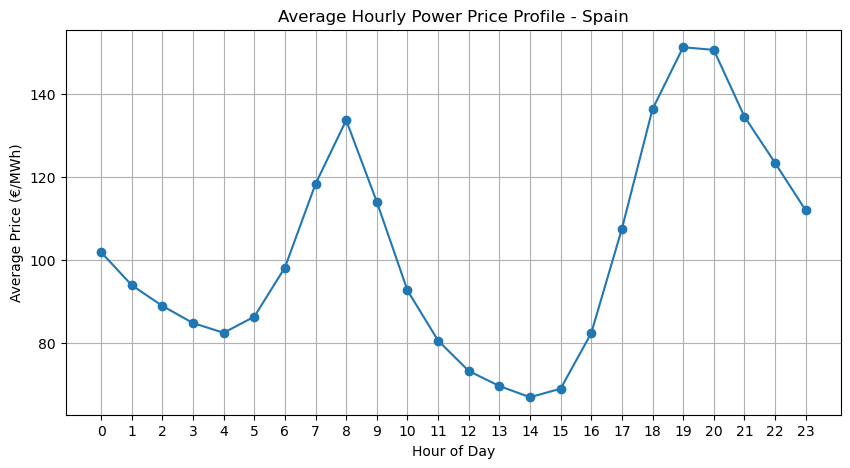

In [26]:
capture_rate = capture_price / baseload_price

print(f"Capture Rate: {capture_rate:.2%}")


negative_hours = (df['price'] < 0).sum()

print(f"Negative price hours: {negative_hours}")

solar_negative = df[df['price'] < 0]['solar_mw'].sum()

solar_total = df['solar_mw'].sum()

share_negative = solar_negative / solar_total

print(f"Solar generation during negative prices: {share_negative:.2%}")



midday = df.between_time('11:00', '15:00')

midday_avg = midday['price'].mean()
#midday solar deperssion is an environemental and energy grid pehnomenon where peak daytime
#drivex extreme power generation. Massive surge when sun sets 
#this is the moment user demand is increasing
print("Solar depression midday average")
print( midday_avg)


##Duck curve, the famous curve of demand and therefore, the lack of flexibility.

hourly_profile = df.groupby(df.index.hour)['price'].mean()

print(hourly_profile)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker='o'
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Price (€/MWh)')
plt.title('Average Hourly Power Price Profile - Spain')

plt.grid(True)

plt.xticks(range(0,24))

plt.show()

# Evening RAMP


Average Evening Ramp: 83.79 €/MWh
Maximum Evening Ramp: 170.41 €/MWh


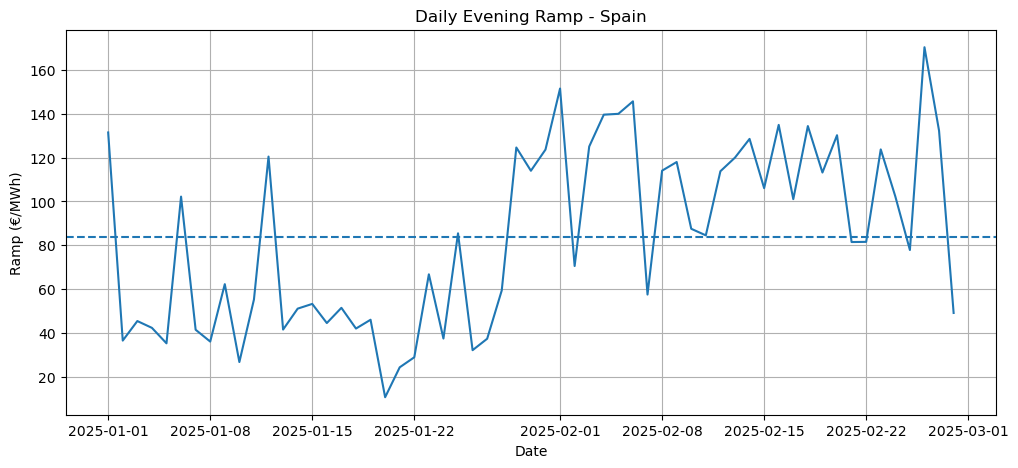

In [27]:
###evening ramp from the duck curve 

price_14h = df[df.index.hour == 14]['price']
price_20h = df[df.index.hour == 20]['price']

ramp_df = pd.DataFrame({
    'price_14h': price_14h.values,
    'price_20h': price_20h.values
}, index=price_14h.index.date)


ramp_df['evening_ramp'] = (
    ramp_df['price_20h']
    - ramp_df['price_14h']
)



avg_ramp = ramp_df['evening_ramp'].mean()

print(f"\nAverage Evening Ramp: {avg_ramp:.2f} €/MWh")

max_ramp = ramp_df['evening_ramp'].max()

print(f"Maximum Evening Ramp: {max_ramp:.2f} €/MWh")


plt.figure(figsize=(12,5))

plt.plot(
    ramp_df.index,
    ramp_df['evening_ramp']
)

plt.axhline(
    avg_ramp,
    linestyle='--'
)

plt.title('Daily Evening Ramp - Spain')
plt.ylabel('Ramp (€/MWh)')
plt.xlabel('Date')

plt.grid(True)

plt.show()

#the evening ramp si the difference between prices at 14 and 20, the goal is to actually have a simple visualisation
#to analyse how prices tend to go up during the evening.

#Battery ramp opp?

In [28]:
#Potential bonus, we need to maybe analyse it furthermore is the Battery arbitrage opportunity. The goal of an arbitrage 
#is to make a profit without taking any risks

battery_mwh = 1

daily_revenue = (
    ramp_df['evening_ramp']
    * battery_mwh
)

print(daily_revenue.head())

2025-01-01    131.49
2025-01-02     36.45
2025-01-03     45.37
2025-01-04     42.27
2025-01-05     35.20
Name: evening_ramp, dtype: float64


Battery Arbitrage Results

Average Daily Profit: 68.72 €
Maximum Daily Profit: 147.91 €
Total Profit: 4054.26 €


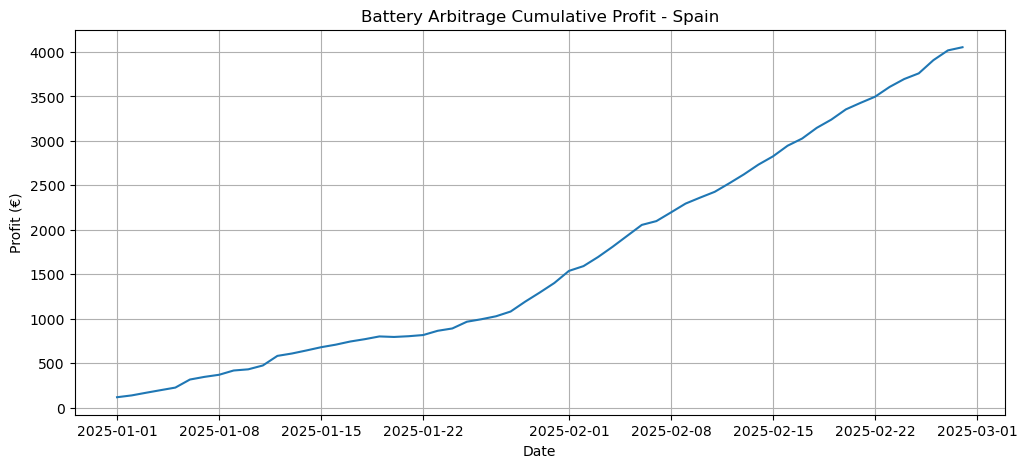

In [29]:
battery_mwh = 1.0
efficiency = 0.90


charge_hour = 14


discharge_hour = 20

# Buy and sell prices
buy_prices = df[df.index.hour == charge_hour]['price']
sell_prices = df[df.index.hour == discharge_hour]['price']


arb_df = pd.DataFrame({
    'buy_price': buy_prices.values,
    'sell_price': sell_prices.values
}, index=buy_prices.index.date)


arb_df['daily_profit'] = (
    (arb_df['sell_price'] * battery_mwh * efficiency)
    - (arb_df['buy_price'] * battery_mwh)
)


print("Battery Arbitrage Results\n")

print(
    f"Average Daily Profit: "
    f"{arb_df['daily_profit'].mean():.2f} €"
)

print(
    f"Maximum Daily Profit: "
    f"{arb_df['daily_profit'].max():.2f} €"
)

print(
    f"Total Profit: "
    f"{arb_df['daily_profit'].sum():.2f} €"
)

# Cumulative profit
arb_df['cumulative_profit'] = (
    arb_df['daily_profit'].cumsum()
)


# PLOT


plt.figure(figsize=(12,5))

plt.plot(
    arb_df.index,
    arb_df['cumulative_profit']
)

plt.title('Battery Arbitrage Cumulative Profit - Spain')

plt.xlabel('Date')

plt.ylabel('Profit (€)')

plt.grid(True)

plt.show()